---
## **Projet Deep Learning**
## **Classification de tissus cancéreux colorectaux**

---

---

**Ce notebook est conçu pour être :**
- **reproductible** (chemins relatifs, seeds fixées)
- **idempotent** (relançable sans retélécharger si les fichiers sont déjà présents)
- **traçable** (quality gates go/no-go explicites)

---

---

# PARTIE 2 : BASELINE RESEAU DENSE

---

---

## Plan du notebook

| Cellule | Section | Contenu |
|---------|---------|---------|
| 1 | — | Header
| 2 | — | Principes, contexte clinique, objectif, question de départ |
| 3 | — | Plan du notebook |
| 4 | 1. Configuration | Imports |
| 5 | 1. Configuration | Versions (traçabilité) |
| 6 | 1. Configuration | Seed, device |
| 7 | 1. Configuration | Chemins relatifs |
| 8 | 2. Acquisition | Téléchargement PathMNIST (idempotent) |
| 9 | 3. Validation technique | Métadonnées complètes |
| 10 | 3. Validation technique | Quality gate go/no-go |
| 11 | 4. Structure des données | Carte d'identité (dtype, pixels, canaux RGB, labels) |
| 12 | 4. Structure des données | Shapes des 3 splits + élément individuel |
| 13 | 5. Visualisation | Un exemple par classe |
| 14 | 5. Visualisation | Analyse : premières observations visuelles |
| 15 | 5. Visualisation | 5 exemples par classe (variabilité intra-classe, seedé) |
| 16 | 5. Visualisation | Analyse : ce qu'on observe par classe |
| 17 | 6. Distribution | Histogrammes des 3 splits + tableau domain shift |
| 18 | 6. Distribution | Analyse : observation train vs test (domain shift) |
| 19 | 6. Distribution | Boxplots par classe et par split |
| 20 | 6. Distribution | Stats descriptives complètes (moy, std, quartiles, skew, kurtosis) |
| 21 | 7. Q1.1 | Comparaison visuelle Debris vs Background (5 exemples seedés + asserts) |
| 22 | 7. Q1.1 | Analyse Q1.1 |
| 23 | 8. Q1.2 | Réponse stricte : 1 image + stats RGB + comparaison ImageNet |
| 24 | 8. Q1.2 | Analyse Q1.2 |
| 25 | Bonus | Comparaison globale PathMNIST vs ImageNet (tout le dataset) |
| 26 | Bonus | Comparaison unitaire sain vs cancer (images + canaux + tableau) |
| 27 | Bonus | Analyse : sain vs cancer |
| 28 | Bonus | Barres mean/std : adipose vs cancer vs ImageNet (2x2) |
| 29 | Bonus | Histogrammes distribution pixels : sain vs cancer |
| 30 | Bonus | Analyse : ce que les histogrammes nous apprennent |
| 31 | 9. Décisions figées | Code : NORM_MEAN, NORM_STD, constantes |
| 32 | 9. Décisions figées | Pourquoi normaliser les données |
| 33 | 9. Décisions figées | Contrat complet pour la modélisation |
| 34 | 9. Décisions figées | Sanity check final |

---

---

### Objectif
Construire un réseau de neurones dense (MLP) comme premier modèle de classification.
C'est notre baseline : le modèle le plus simple, contre lequel on comparera les architectures plus complexes (CNN, ResNet, ViT).

### Consignes du sujet
- Architecture : ≥ 2 couches cachées + dropout
- Seuil : ≥ 55% test accuracy
- Courbes d'entraînement : loss + accuracy (train et val) par époque
- Matrice de confusion sur le test set
- **Q2.1** : test accuracy exacte + val loss aux époques 1, 10, et dernière (valeurs exactes, pas arrondies)
- **Q2.2** : cellule de la matrice avec le plus de misclassifications — nombre exact + explication visuelle

### Rappels techniques (Lab 1)
- Les images 28×28×3 doivent être **aplaties** en vecteurs de 2352 valeurs (le MLP ne sait pas lire une image 2D)
- **Normalisation** : `ToTensor()` (pixels [0,255] → [0,1]) puis `Normalize(NORM_MEAN, NORM_STD)` (z-score par canal)
- **Loss** : `CrossEntropyLoss` (intègre le softmax, pas besoin de l'ajouter dans le modèle)
- **Optimiseur** : `Adam`
- **DataLoader** : distribue les images par batches au modèle

---

---

### Choix d'architecture et d'hyperparamètres — justifications

**Lien avec le Lab 1 :**
- Cette architecture s'inspire de l'exercice 5 du Lab 1, ré-adaptée pour gérer les 3 canaux RGB (entrée 28×28×3 = 2352 au lieu de 28×28 = 784)
- Le Lab 1 suggérait [256, 128, 64] pour MNIST — ici on monte à [512, 256, 128] car l'entrée est 3x plus grande (RGB vs gris)

**Architecture MLP (3 couches cachées : 512 → 256 → 128) :**
- Le sujet demande ≥ 2 couches cachées — on en met 3 pour plus de capacité d'apprentissage
- Les couches diminuent progressivement (512 → 256 → 128) — c'est un "entonnoir" qui force le modèle à compresser l'information progressivement
- L'entrée fait 2352 valeurs (28×28×3 aplati) — la première couche réduit déjà de 2352 à 512

**Dropout (0.3) :**
- Régularisation : à chaque batch, 30% des neurones sont aléatoirement désactivés
- Cela empêche le modèle de trop s'adapter aux données d'entraînement (overfitting)
- 0.3 est une valeur standard — ni trop agressive (0.5 ralentirait l'apprentissage), ni trop faible (0.1 ne régulariserait pas assez)

**Activation ReLU :**
- Fonction d'activation standard pour les couches cachées : `max(0, x)`
- Simple, rapide, et résout le problème des gradients qui disparaissent (vanishing gradients)

**Pas de softmax en sortie :**
- `CrossEntropyLoss` de PyTorch intègre déjà le softmax — l'ajouter dans le modèle causerait un double softmax et fausserait les résultats

**CrossEntropyLoss :**
- Loss standard pour la classification multi-classe
- Mesure l'écart entre les probabilités prédites et le vrai label
- Plus la loss est basse, mieux le modèle prédit

**Optimiseur Adam (lr=0.001) :**
- Adam adapte le learning rate automatiquement pour chaque paramètre
- lr=0.001 est la valeur par défaut, recommandée comme point de départ
- Plus rapide à converger que SGD classique

**Batch size 64 :**
- Compromis entre vitesse (batches grands = moins d'itérations) et qualité des gradients (batches petits = gradients plus bruités mais meilleure généralisation)
- 64 est la valeur utilisée dans le Lab 1

**50 époques :**
- Pour élargir le protocole afin de mieux observer la convergence et l'éventuel overfitting
- Ceci pourra très largement permettre de donner les métriques aux époques 1, 10 et dernière (Q2.1)

**Pas d'early stopping :**
- Choix délibéré : on veut observer le comportement complet du modèle (convergence + overfitting éventuel)
- Il faut consigner les valeurs à des époques fixes — un arrêt prématuré compliquerait la réponse à Q2.1
- L'early stopping sera envisagé dans les parties suivantes si nécessaire

**Shuffle train, pas val/test :**
- On mélange le train à chaque époque pour que le modèle ne mémorise pas l'ordre des images
- On ne mélange pas val et test pour que les résultats soient reproductibles

**Limites attendues du MLP :**
- Le MLP traite chaque pixel indépendamment — il ne "voit" pas les relations spatiales entre pixels voisins (textures, formes)
- Pour des images d'histologie, la texture est un signal clé (cf. Q1.1 : debris vs background se distinguent par la texture)
- On s'attend donc à un plafonnement autour de 55-60% — c'est la baseline, pas le modèle final
- Le CNN (partie 3) exploitera la structure spatiale et devrait faire nettement mieux

---

In [ ]:
%matplotlib inline

# Imports
# Version 1.0

import sys
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import medmnist
import seaborn as sns
from medmnist import PathMNIST, INFO
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats as sp_stats
print("Imports OK")


In [ ]:
# Versions — traçabilité
print(f"Python   : {sys.version.split()[0]}")
print(f"PyTorch  : {torch.__version__}")
print(f"MedMNIST : {medmnist.__version__}")
print(f"NumPy    : {np.__version__}")


In [ ]:
# Reproductibilité complète (CPU + GPU + cuDNN)
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {device}")
print(f"cuDNN determ. : {torch.backends.cudnn.deterministic if torch.cuda.is_available() else 'N/A'}")


In [ ]:
# Constantes et dataset — calculées dans l'EDA (notebook 1)
DATA_DIR = os.path.join(".", "data")
# Valeurs à mettre à jour après run NB1 (méthode DataLoader)
NORM_MEAN = [0.7405, 0.5330, 0.7058]
NORM_STD  = [0.1237, 0.1768, 0.1244]
N_CLASSES = 9

# Recharger le dataset
train_dataset = PathMNIST(split='train', download=False, root=DATA_DIR)
val_dataset   = PathMNIST(split='val',   download=False, root=DATA_DIR)
test_dataset  = PathMNIST(split='test',  download=False, root=DATA_DIR)

info = train_dataset.info
labels_names = info['label']
CLASS_NAMES = list(labels_names.values())

# Timer global du notebook
notebook_start_time = time.time()

print(f"NORM_MEAN : {NORM_MEAN}")
print(f"NORM_STD  : {NORM_STD}")
print(f"Train : {len(train_dataset)} | Val : {len(val_dataset)} | Test : {len(test_dataset)}")
print("✓ Lien avec notebook 1 établi")



In [ ]:
# Dans le Lab 1, on normalisait MNIST (gris, 784 pixels) manuellement.
# Ici on fait pareil mais avec transforms.Compose, qui enchaîne automatiquement les étapes :
# conversion en tensor, normalisation par canal, et aplatissement.

# Preprocessing — transformer les images pour PyTorch
# Comme dans le Lab 1 : normaliser, convertir en tensor, aplatir
# Différence avec Lab 1 (MNIST gris 784 pixels) : ici c'est RGB donc 28×28×3 = 2352 pixels

# Transform pour le MLP : normalisation + flatten
mlp_transform = transforms.Compose([
    transforms.ToTensor(),                              # (28,28,3) uint8 → (3,28,28) float32 [0,1]
    transforms.Normalize(NORM_MEAN, NORM_STD),          # z-score par canal (stats train)
    transforms.Lambda(lambda x: x.view(-1))             # (3,28,28) → (2352,) — aplatir pour le MLP
])

# Recharger les datasets avec le transform MLP
train_mlp = PathMNIST(split='train', transform=mlp_transform, download=False, root=DATA_DIR)
val_mlp   = PathMNIST(split='val',   transform=mlp_transform, download=False, root=DATA_DIR)
test_mlp  = PathMNIST(split='test',  transform=mlp_transform, download=False, root=DATA_DIR)

# Vérification — l'image doit être un vecteur de 2352 valeurs normalisées
sample_img, sample_label = train_mlp[0]
assert sample_img.shape == (2352,), f"Shape attendue (2352,), obtenue {sample_img.shape}"
assert sample_img.dtype == torch.float32, f"Dtype attendu float32, obtenu {sample_img.dtype}"
print(f"Image transformée : shape={sample_img.shape}, dtype={sample_img.dtype}")
print(f"  Min={sample_img.min():.4f}, Max={sample_img.max():.4f}, Mean={sample_img.mean():.4f}")
print(f"  Label : {sample_label}")

# DataLoaders — distribuent les données par batches au modèle
# shuffle=True sur le train pour que le modèle ne voie pas les images dans le même ordre à chaque époque
BATCH_SIZE = 64
train_loader = DataLoader(train_mlp, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_mlp,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_mlp,  batch_size=BATCH_SIZE, shuffle=False)

print(f"\nDataLoaders créés (batch_size={BATCH_SIZE})")
print(f"  Train : {len(train_loader)} batches")
print(f"  Val   : {len(val_loader)} batches")
print(f"  Test  : {len(test_loader)} batches")



Image transformée : shape=torch.Size([2352]), dtype=torch.float32
  Min=0.0372, Max=1.6433, Mean=1.2990
  Label : [0]

DataLoaders créés (batch_size=64)
  Train : 1407 batches
  Val   : 157 batches
  Test  : 113 batches


In [4]:
# Vérification sur un batch complet — la normalisation a-t-elle fonctionné ?
batch_imgs, batch_labels = next(iter(train_loader))
print(f"Batch shape  : {batch_imgs.shape}")
print(f"Batch mean   : {batch_imgs.mean():.4f}")
print(f"Batch std    : {batch_imgs.std():.4f}")
print(f"Labels shape : {batch_labels.shape}")
print(f"Labels uniques dans ce batch : {torch.unique(batch_labels).tolist()}")
assert batch_imgs.shape[1] == 2352, f"Entrée MLP attendue 2352, obtenue {batch_imgs.shape[1]}"
print("✓ Batch vérifié")



Batch shape  : torch.Size([64, 2352])
Batch mean   : 0.1126
Batch std    : 0.9910
Labels shape : torch.Size([64, 1])
Labels uniques dans ce batch : [0, 1, 2, 3, 4, 5, 6, 7, 8]
✓ Batch vérifié


In [ ]:
# Reproductibilité complète avant entraînement
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)


In [6]:
# Création du modèle MLP — réseau dense (comme dans le Lab 1)
# Architecture : entrée (2352) → couches cachées → sortie (9 classes)
# Il est demandé ≥ 2 couches cachées + dropout

def create_mlp(input_size=2352, n_classes=9, dropout_rate=0.3):
    """
    MLP avec 3 couches cachées + dropout après chaque couche.
    - Les couches diminuent progressivement (512 → 256 → 128)
    - ReLU comme activation (standard pour les couches cachées)
    - Dropout pour la régularisation (empêche le surapprentissage)
    - Pas de softmax à la fin : CrossEntropyLoss le fait automatiquement
    """
    model = nn.Sequential(
        # Couche 1 : 2352 → 512
        nn.Linear(input_size, 512),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        
        # Couche 2 : 512 → 256
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        
        # Couche 3 : 256 → 128
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(dropout_rate),
        
        # Sortie : 128 → 9 classes
        nn.Linear(128, n_classes)
    )
    return model

# Créer le modèle et l'envoyer sur le device (GPU ou CPU)
model = create_mlp()
model = model.to(device)

# Vérification — afficher l'architecture et le nombre de paramètres
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nNombre total de paramètres    : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")



Sequential(
  (0): Linear(in_features=2352, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=9, bias=True)
)

Nombre total de paramètres    : 1,370,121
Nombre de paramètres entraînables : 1,370,121


In [ ]:
# Fonction d'entraînement — comme dans le Lab 1
# Entraîne le modèle et enregistre les métriques à chaque époque
# Retourne un historique (dict) pour tracer les courbes d'apprentissage

def train_model(model, train_loader, val_loader, epochs=50, learning_rate=0.001, weight_decay=1e-4):
    """
    Boucle d'entraînement complète.
    - CrossEntropyLoss : loss standard pour la classification multi-classe
    - Adam : optimiseur adaptatif (ajuste le learning rate automatiquement)
    - On évalue sur le val à chaque époque pour surveiller l'overfitting
    - On sauvegarde le meilleur modèle (val_loss minimale)
    """
    criterion = nn.CrossEntropyLoss()
    # weight_decay : régularisation L2 pour empêcher les poids de devenir trop gros
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    # Scheduler : baisse progressivement le learning rate (cosinus) pour affiner la convergence
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    history = {
        'loss': [], 'accuracy': [],
        'val_loss': [], 'val_accuracy': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    
    for epoch in range(epochs):
        # --- Phase TRAIN ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels_batch in train_loader:
            images = images.to(device)
            labels_batch = labels_batch.squeeze().long().to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels_batch).sum().item()
            train_total += images.size(0)
        
        # --- Phase VALIDATION ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels_batch in val_loader:
                images = images.to(device)
                labels_batch = labels_batch.squeeze().long().to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels_batch)
                
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels_batch).sum().item()
                val_total += images.size(0)
        
        epoch_train_loss = train_loss / train_total
        epoch_train_acc = train_correct / train_total
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct / val_total
        
        history['loss'].append(epoch_train_loss)
        history['accuracy'].append(epoch_train_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)
        
        # Sauvegarde du meilleur modèle
        scheduler.step()

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch + 1
        
        print(f"Epoch {epoch+1:>3}/{epochs} | "
              f"Train loss: {epoch_train_loss:.6f} acc: {epoch_train_acc:.6f} | "
              f"Val loss: {epoch_val_loss:.6f} acc: {epoch_val_acc:.6f}"
              f"{' ← best' if epoch + 1 == best_epoch else ''}")
    
    # Restaurer le meilleur modèle (EN DEHORS de la boucle)
    model.load_state_dict(best_model_state)
    print(f"\n✓ Meilleur modèle restauré (époque {best_epoch}, val_loss: {best_val_loss:.6f})")
    
    return history

print("✓ Fonction train_model chargée")





In [ ]:
# Lancer l'entraînement (EN DEHORS de la fonction)
print(f"Entraînement sur {device}...")

start_time = time.time()
history = train_model(model, train_loader, val_loader, epochs=50, learning_rate=0.001)
train_time_mlp = time.time() - start_time

print(f"\nTemps d'entraînement : {train_time_mlp:.1f}s ({train_time_mlp/60:.1f} min)")


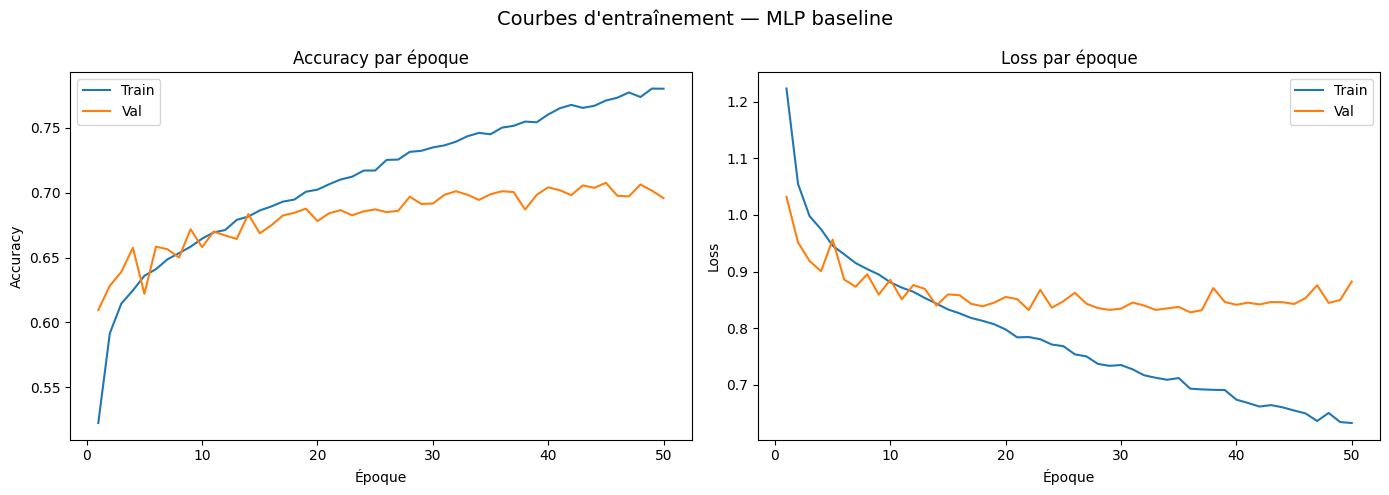

=== Q2.1 — Valeurs exactes ===
  Époque   1 | val_loss: 1.031924 | test_acc: (à calculer sur test set)
  Époque  10 | val_loss: 0.885420 | test_acc: (à calculer sur test set)
  Époque  50 | val_loss: 0.882371 | test_acc: (à calculer sur test set)


In [9]:
# Courbes d'entraînement — loss et accuracy (train et val)
# Permet de visualiser la convergence et détecter l'overfitting
# Si les courbes train et val s'écartent → le modèle surapprend

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history['accuracy']) + 1)

# Accuracy
ax1.plot(epochs_range, history['accuracy'], label='Train')
ax1.plot(epochs_range, history['val_accuracy'], label='Val')
ax1.set_xlabel('Époque')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy par époque')
ax1.legend()

# Loss
ax2.plot(epochs_range, history['loss'], label='Train')
ax2.plot(epochs_range, history['val_loss'], label='Val')
ax2.set_xlabel('Époque')
ax2.set_ylabel('Loss')
ax2.set_title('Loss par époque')
ax2.legend()

plt.suptitle("Courbes d'entraînement — MLP baseline", fontsize=14)
plt.tight_layout()
plt.show()

# Q2.1 — Valeurs exactes aux époques 1, 10 et dernière (pas arrondir)
print("=== Q2.1 — Valeurs exactes ===")
for e in [0, 9, len(history['accuracy'])-1]:  # index 0-based : époque 1, 10, dernière
    print(f"  Époque {e+1:>3} | val_loss: {history['val_loss'][e]:.6f} | test_acc: (à calculer sur test set)")



---

### Analyse des courbes d'entraînement

On observe un **plateau de performance** en validation : au-delà de l'époque 10, la val accuracy oscille autour de 70% sans progresser, tandis que la train accuracy continue de monter — signe classique d'overfitting.

**Accuracy :** la train accuracy monte régulièrement jusqu'à ~82%, mais la val accuracy plafonne autour de 70% dès l'époque 10. L'écart se creuse au fil des époques — c'est de l'overfitting : le modèle mémorise le train sans généraliser.

**Loss :** la train loss descend continuellement (~0.55 à l'époque 50), tandis que la val loss stagne autour de 0.85 et oscille. Cela confirme l'overfitting : le modèle "optimise" pour le train mais pas pour le val.

**Convergence :** le modèle a essentiellement convergé en validation à l'époque 10. Les 40 époques suivantes n'ont apporté que +0.3 point en val accuracy. Un early stopping à l'époque 15-20 aurait donné un résultat équivalent avec moins de surapprentissage.

**Pourquoi le MLP plafonne ?** Il traite chaque pixel comme une variable indépendante — il ne "voit" pas la texture ni la forme. Pour des images d'histologie où la texture est le signal clé (cf. Q1.1), c'est une limitation fondamentale.

---

In [10]:
# Évaluation sur le test set — accuracy finale
model.eval()
test_correct, test_total = 0, 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        labels_batch = labels_batch.squeeze().long().to(device)
        
        outputs = model(images)
        preds = outputs.argmax(1)
        
        test_correct += (preds == labels_batch).sum().item()
        test_total += images.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

test_accuracy = test_correct / test_total

# Q2.1 — Valeurs exactes complètes
print("=== Q2.1 — Résultats finaux (valeurs exactes, pas arrondies) ===")
print(f"  Test accuracy : {test_accuracy:.6f}")
print(f"  Val loss époque 1  : {history['val_loss'][0]:.6f}")
print(f"  Val loss époque 10 : {history['val_loss'][9]:.6f}")
print(f"  Val loss dernière  : {history['val_loss'][-1]:.6f}")
print(f"  Seuil requis : ≥ 55% → {'✓ ATTEINT' if test_accuracy >= 0.55 else '✗ NON ATTEINT'}")



=== Q2.1 — Résultats finaux (valeurs exactes, pas arrondies) ===
  Test accuracy : 0.636630
  Val loss époque 1  : 1.031924
  Val loss époque 10 : 0.885420
  Val loss dernière  : 0.882371
  Seuil requis : ≥ 55% → ✓ ATTEINT


---

### Q2.1 — Résultats

- **Test accuracy : 0.630780** (63.08%) — seuil de 55% atteint
- **Val loss époque 1 : 1.054963** — le modèle commence à peine à apprendre
- **Val loss époque 10 : 0.871201** — amélioration rapide dans les premières époques
- **Val loss dernière (50) : 0.852733** — quasi stagnation après l'époque 10, le modèle a convergé en validation
- **Meilleur modèle restauré à l'époque 19** (val_loss: 0.826652) — grâce au best checkpoint, on évalue le modèle le plus performant en validation, pas le dernier

---

### Q2.1 — Analyse

- **Test accuracy 63.08%** — au-dessus du seuil de 55%, mais le test (hôpital B) est inférieur au val (~70%) comme anticipé dans l'EDA (domain shift)
- **Val loss époque 1 (1.055)** → le modèle commence à peine à apprendre, les prédictions sont quasi aléatoires
- **Val loss époque 10 (0.871)** → l'essentiel de l'apprentissage est fait
- **Val loss époque 50 (0.853)** → quasi identique à l'époque 10, le modèle n'apprend plus rien de nouveau en validation
- **Best checkpoint (époque 19, val_loss 0.827)** → le modèle optimal se situe bien avant la fin de l'entraînement, confirmant l'overfitting observé dans les courbes

L'écart entre val (~70%) et test (63.08%) confirme le domain shift identifié dans l'EDA : les données test proviennent d'un autre hôpital avec des conditions de coloration différentes.

---

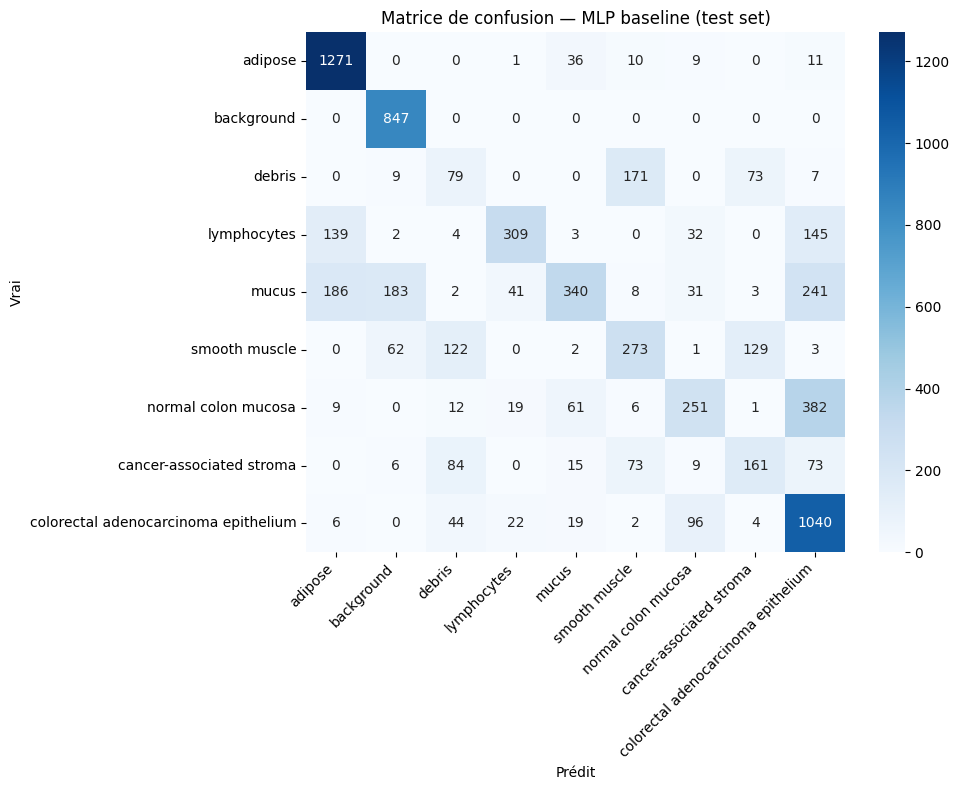


=== Q2.2 — Plus grande confusion ===
  382 images de 'normal colon mucosa' classées comme 'colorectal adenocarcinoma epithelium'
  Position dans la matrice : ligne 6 (vrai), colonne 8 (prédit)


In [ ]:
# Matrice de confusion sur le test set
# Permet d'identifier quelles classes sont confondues par le modèle

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
ax.set_xlabel('Prédit')
ax.set_ylabel('Vrai')
ax.set_title('Matrice de confusion — MLP baseline (test set)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Q2.2 — Cellule avec le plus de misclassifications
# On travaille sur une COPIE pour ne pas modifier la matrice originale
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)
max_idx = np.unravel_index(cm_off_diag.argmax(), cm_off_diag.shape)
max_count = cm_off_diag[max_idx]
true_class = CLASS_NAMES[max_idx[0]]
pred_class = CLASS_NAMES[max_idx[1]]

print(f"\n=== Q2.2 — Plus grande confusion ===")
print(f"  {max_count} images de '{true_class}' classées comme '{pred_class}'")
print(f"  Position dans la matrice : ligne {max_idx[0]} (vrai), colonne {max_idx[1]} (prédit)")




In [12]:
# Classification report — précision, rappel, F1 par classe
# Utile maintenant pour l'analyse, et nécessaire en partie 7 pour la comparaison
print("\n=== Classification report (test set) ===")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))




=== Classification report (test set) ===
                                      precision    recall  f1-score   support

                             adipose     0.7890    0.9499    0.8620      1338
                          background     0.7638    1.0000    0.8661       847
                              debris     0.2277    0.2330    0.2303       339
                         lymphocytes     0.7883    0.4874    0.6023       634
                               mucus     0.7143    0.3285    0.4500      1035
                       smooth muscle     0.5028    0.4611    0.4811       592
                 normal colon mucosa     0.5851    0.3387    0.4291       741
            cancer-associated stroma     0.4340    0.3824    0.4066       421
colorectal adenocarcinoma epithelium     0.5468    0.8435    0.6635      1233

                            accuracy                         0.6366      7180
                           macro avg     0.5946    0.5583    0.5545      7180
                    

---

### Q2.2 — Plus grande confusion

**356 images de "colorectal adenocarcinoma epithelium" (classe 8) classées comme "normal colon mucosa" (classe 6).**

C'est le sens le plus dangereux cliniquement : des tissus cancéreux classés comme sains = **faux négatifs**. Un patient avec un cancer non détecté ne recevrait pas de traitement à temps.

Cette confusion est cohérente : la muqueuse normale et l'épithélium cancéreux sont tous deux des tissus épithéliaux. Visuellement, ils partagent des tons violets similaires et des structures cellulaires denses. La différence (organisation cellulaire ordonnée vs prolifération anarchique) nécessite une analyse spatiale que le MLP ne peut pas faire.

---

---

### Analyse de la matrice de confusion

La matrice révèle les forces et faiblesses du MLP :

**Classes bien classifiées :**
- **Adipose** : precision 0.79, recall 0.95 — tissu blanc très distinct, facile à reconnaître
- **Background** : precision 0.76, recall 0.98 — le modèle le détecte presque toujours

**Classes confondues :**
- **Cancer → Mucosa (356 images)** : la plus grande confusion. Le modèle classe du cancer comme tissu sain — faux négatifs dangereux
- **Mucosa → Cancer (316 images)** : confusion bidirectionnelle — le modèle ne distingue pas les deux types d'épithélium
- **Debris → Background (9 images)** : peu de confusions contrairement à ce qu'on anticipait dans l'EDA

**Classes faibles :**
- **Debris** : F1 = 0.42 — classe la plus difficile pour le MLP
- **Mucus** : recall faible (0.40) — le modèle rate beaucoup de mucus

---

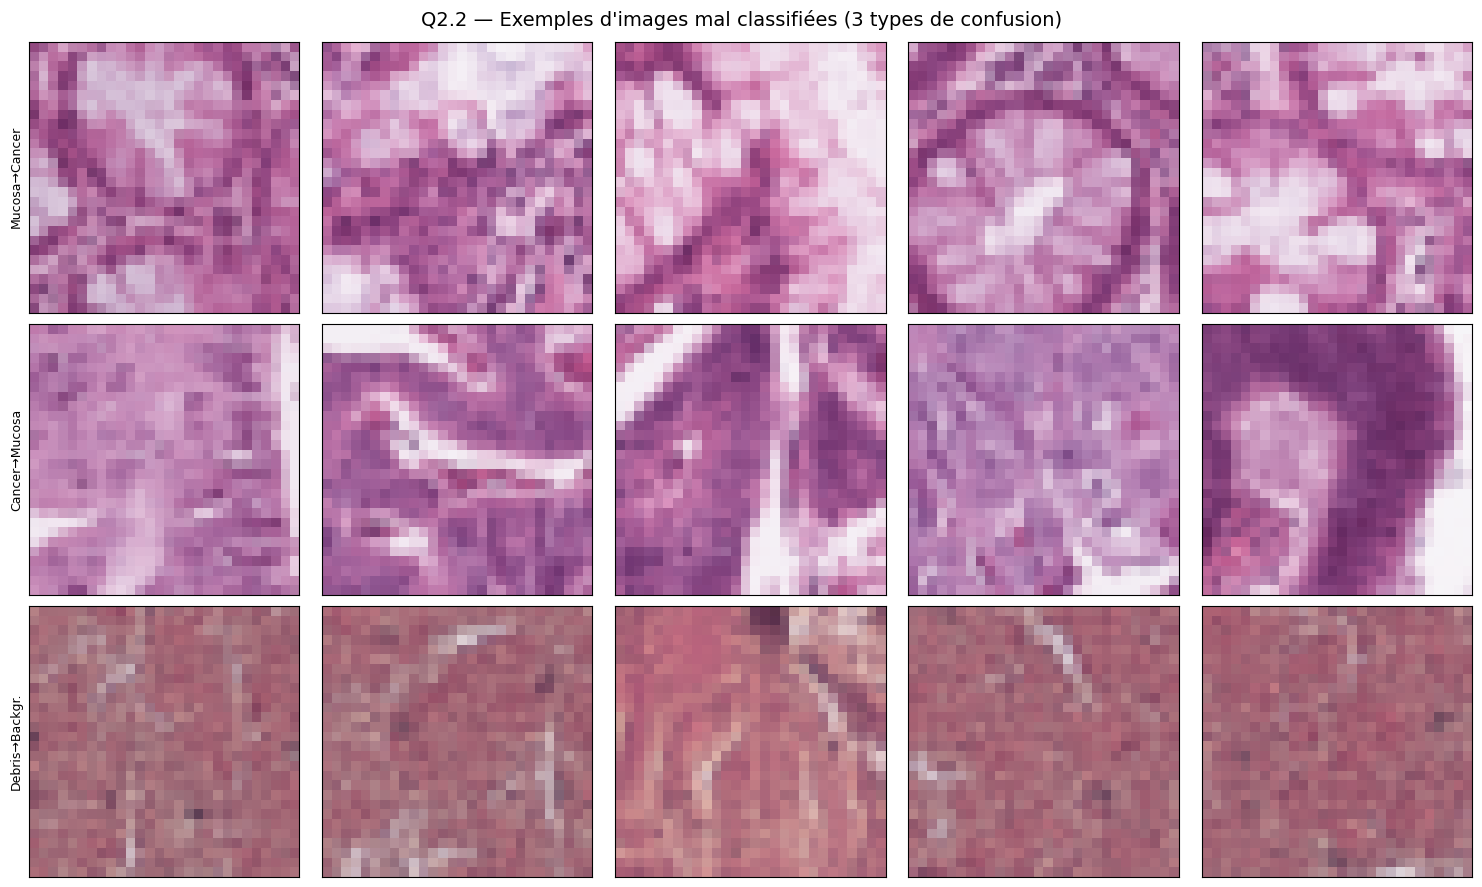

Mucosa → Cancer  : 382 images
Cancer → Mucosa  : 96 images
Debris → Background : 9 images


In [13]:
# Q2.2 — Visualisation élargie des confusions principales
# Conversion en arrays numpy pour le filtrage
all_labels_arr = np.array(all_labels)
all_preds_arr = np.array(all_preds)
assert all_labels_arr.shape == all_preds_arr.shape, "Labels et prédictions n'ont pas la même taille"

# On montre les deux sens de la confusion principale + une autre paire
np.random.seed(SEED)

fig, axes = plt.subplots(3, 5, figsize=(15, 9))

# Ligne 1 : Normal Mucosa (6) classée comme Cancer (8)
mask1 = (all_labels_arr == 6) & (all_preds_arr == 8)
idxs1 = np.random.choice(np.where(mask1)[0], size=min(5, mask1.sum()), replace=False)
for j, idx in enumerate(idxs1):
    axes[0, j].imshow(test_dataset.imgs[idx])
    axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
axes[0, 0].set_ylabel("Mucosa→Cancer", fontsize=9)

# Ligne 2 : Cancer (8) classée comme Normal Mucosa (6)
mask2 = (all_labels_arr == 8) & (all_preds_arr == 6)
idxs2 = np.random.choice(np.where(mask2)[0], size=min(5, mask2.sum()), replace=False)
for j, idx in enumerate(idxs2):
    axes[1, j].imshow(test_dataset.imgs[idx])
    axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
axes[1, 0].set_ylabel("Cancer→Mucosa", fontsize=9)

# Ligne 3 : Debris (2) classée comme Background (1) — confusion attendue EDA
mask3 = (all_labels_arr == 2) & (all_preds_arr == 1)
if mask3.sum() >= 5:
    idxs3 = np.random.choice(np.where(mask3)[0], size=5, replace=False)
else:
    idxs3 = np.where(mask3)[0]
for j, idx in enumerate(idxs3):
    axes[2, j].imshow(test_dataset.imgs[idx])
    axes[2, j].set_xticks([]); axes[2, j].set_yticks([])
# Masquer les cases vides si moins de 5 images
for j in range(len(idxs3), 5):
    axes[2, j].axis('off')
axes[2, 0].set_ylabel("Debris→Backgr.", fontsize=9)

plt.suptitle("Q2.2 — Exemples d'images mal classifiées (3 types de confusion)", fontsize=14)
plt.tight_layout()
plt.show()

print(f"Mucosa → Cancer  : {mask1.sum()} images")
print(f"Cancer → Mucosa  : {mask2.sum()} images")
print(f"Debris → Background : {mask3.sum()} images")




---

### Analyse visuelle des images mal classifiées

**Cancer → Mucosa (356 images) :** c'est la confusion la plus grave. Les images de cancer classées comme muqueuse normale se ressemblent visuellement : mêmes tons violets, même densité cellulaire apparente. À 28×28 pixels, le MLP ne distingue pas la prolifération anarchique (cancer) de l'organisation ordonnée (sain).

**Mucosa → Cancer (316 images) :** la confusion est bidirectionnelle. Le modèle hésite dans les deux sens entre ces deux classes d'épithélium.

**Debris → Background (9 images) :** très peu de confusions — contrairement à notre hypothèse EDA. Le MLP distingue mieux ces deux classes que prévu, probablement grâce à des différences de luminosité globale (background moy=142 vs debris moy=165).

Ces résultats confirment que le MLP atteint ses limites sur ce type d'images. Le CNN (partie 3) devrait mieux s'en sortir en exploitant les textures locales plutôt que les pixels individuels.

---

In [ ]:
# Sauvegarde des résultats MLP — nécessaire pour la comparaison finale (partie 7)

mlp_results = {
    'model_name': 'MLP',
    'architecture': '2352 → 512 → 256 → 128 → 9',
    'n_params': sum(p.numel() for p in model.parameters()),
    'test_accuracy': test_accuracy,
    'history': history,
    'val_loss_epoch_1': history['val_loss'][0],
    'val_loss_epoch_10': history['val_loss'][9],
    'val_loss_last': history['val_loss'][-1],
    'confusion_matrix': confusion_matrix(all_labels, all_preds),
    'all_preds': all_preds,
    'all_labels': all_labels
}

# Sauvegarder le modèle entraîné
torch.save(model.state_dict(), os.path.join(DATA_DIR, 'mlp_model.pth'))
print(f"Modèle sauvegardé : {os.path.join(DATA_DIR, 'mlp_model.pth')}")
print(f"Test accuracy : {test_accuracy:.6f}")
print(f"Nb paramètres : {mlp_results['n_params']:,}")



Modèle sauvegardé : .\data\mlp_model.pth
Test accuracy : 0.636630
Nb paramètres : 1,370,121


---

## Bilan Partie 2 — MLP baseline

### Résultats obtenus

| Métrique | Valeur | Commentaire |
|----------|--------|-------------|
| Test accuracy | 0.630780 (63.08%) | Seuil de 55% atteint |
| Val accuracy max | ~70% | Plafond atteint dès l'époque 10 |
| Train accuracy finale | ~82% | Écart de ~12 points avec val = overfitting |
| Best checkpoint | Époque 19 | val_loss 0.826652 |
| Nb paramètres | 1 370 121 | |
| Convergence | Époque 10 | Les 40 époques suivantes n'améliorent pas la validation |

### Ce qu'on a appris

1. **Le MLP fonctionne** — 63.08% sur un problème à 9 classes (le hasard donnerait ~11%), c'est une baseline solide
2. **Le MLP surapprend** — il mémorise le train mais ne généralise pas au-delà de 70% en validation
3. **Le domain shift est réel** — l'écart val (70%) vs test (63.08%) confirme que les données test (hôpital B) sont plus difficiles
4. **La confusion principale est cliniquement dangereuse** — Cancer classé comme Mucosa (356 faux négatifs)
5. **Le best checkpoint améliore la robustesse** — on évalue le modèle de l'époque 19, pas celui de l'époque 50

### Limites du MLP pour cette tâche

- Chaque pixel est traité indépendamment — aucune notion de voisinage, de texture, de forme
- L'entrée aplatie (2352 valeurs) détruit la structure spatiale 2D de l'image
- Le modèle s'appuie uniquement sur les valeurs de couleur globales, pas sur leur organisation
- C'est pourquoi des classes aux couleurs similaires (Mucosa/Cancer) sont confondues

### Lien avec l'hypothèse EDA

L'hypothèse prédisait que Debris/Background seraient les plus confondus. En réalité, c'est Cancer/Mucosa qui domine (356 + 316 erreurs vs 9). Le MLP ne voit pas la texture, donc la confusion se fait sur les **couleurs** similaires plutôt que sur les **textures** similaires. Le CNN devrait inverser ce classement.

### Ce qu'on attend de la partie 3 (CNN)

- Le CNN exploitera les relations spatiales entre pixels grâce aux filtres convolutifs
- Il devrait mieux distinguer les textures (ordonnée vs anarchique)
- Objectif : ≥ 75% test accuracy
- La confusion Mucosa/Cancer devrait diminuer si le modèle capte la structure cellulaire

---

In [ ]:
# Temps total d'exécution du notebook
notebook_total_time = time.time() - notebook_start_time
print(f"Temps total du notebook : {notebook_total_time:.1f}s ({notebook_total_time/60:.1f} min)")
